In [5]:
import os
os.getcwd()

'C:\\Users\\jadde'

In [8]:
import glob
glob.glob(r"C:\Users\jadde\**\supply_chain_data.csv", recursive=True)

['C:\\Users\\jadde\\OneDrive\\Desktop\\Kaggle Supplychain Dataset\\supply_chain_data.csv']

In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\jadde\OneDrive\Desktop\Kaggle Supplychain Dataset\supply_chain_data.csv")
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [11]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [12]:
import matplotlib.pyplot as plt

revenue_by_product = df.groupby('Product type')['Revenue generated'].sum().sort_values(ascending=False)
print(revenue_by_product)

Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64


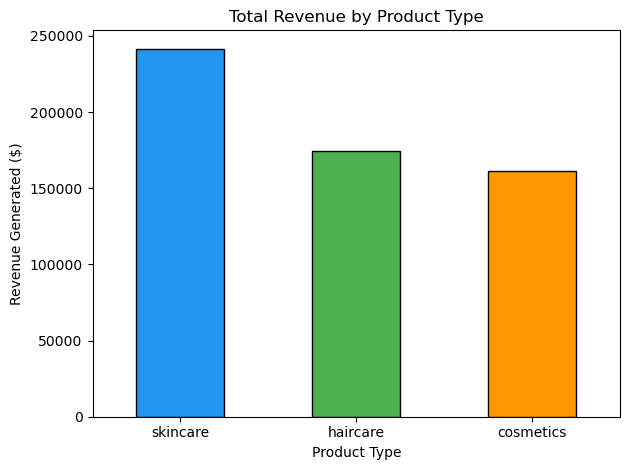

In [13]:
revenue_by_product.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='black')
plt.title('Total Revenue by Product Type')
plt.xlabel('Product Type')
plt.ylabel('Revenue Generated ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Shipping carriers
Carrier B    5.509247
Carrier A    5.554923
Carrier C    5.599292
Name: Shipping costs, dtype: float64


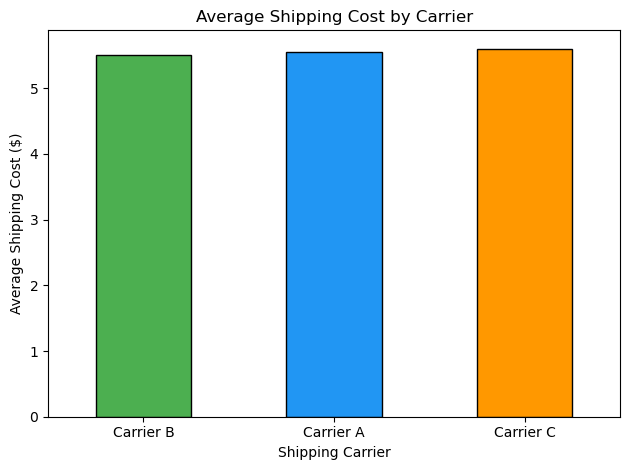

In [14]:
carrier_cost = df.groupby('Shipping carriers')['Shipping costs'].mean().sort_values()
print(carrier_cost)

carrier_cost.plot(kind='bar', color=['#4CAF50', '#2196F3', '#FF9800'], edgecolor='black')
plt.title('Average Shipping Cost by Carrier')
plt.xlabel('Shipping Carrier')
plt.ylabel('Average Shipping Cost ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

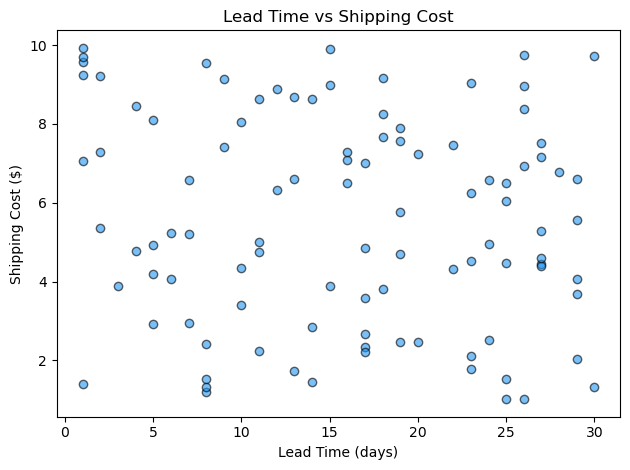

In [15]:
plt.scatter(df['Lead times'], df['Shipping costs'], alpha=0.6, color='#2196F3', edgecolors='black')
plt.title('Lead Time vs Shipping Cost')
plt.xlabel('Lead Time (days)')
plt.ylabel('Shipping Cost ($)')
plt.tight_layout()
plt.show()

In [16]:
# Supply Chain Analysis - Key Findings
# Dataset: 100 products across 3 categories (Skincare, Haircare, Cosmetics)

# Finding 1: Skincare generates the highest total revenue (~$241K), 
#             outperforming cosmetics by ~33%

# Finding 2: Shipping costs are nearly identical across all 3 carriers (~$5.50 avg),
#             suggesting no cost advantage in carrier selection

# Finding 3: No correlation between lead time and shipping cost,
#             indicating pricing is driven by other factors